## Imports

In [53]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from PIL import Image, UnidentifiedImageError
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.applications import (
    EfficientNetV2S, EfficientNetB3,
    ResNet50V2, MobileNetV3Large, DenseNet121,
    VGG16
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

keras.mixed_precision.set_global_policy('float32')

RAW_DATASET_DIR = Path("C:/Users/mariana/Downloads/wikiart")
CLEAN_DATASET_DIR = Path("dataset/wikiart_clean")
SPLIT_DATASET_DIR = Path("dataset/wikiart_split")

IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
MIN_WIDTH = 64
MIN_HEIGHT = 64

TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15

RANDOM_STATE = 42

assert abs(TRAIN_SIZE + VAL_SIZE + TEST_SIZE - 1.0) < 1e-6, "Os splits têm de somar 1."

Keeping only valid images and organising the dataset:
- `is_valid_image_file` checks if the extension is a valid format.
- `clean_dataset` checks if the files are corrupted, converts to RGB format, filters by size (64/64) and padronises it to .jpg

In [26]:
def is_valid_image_file(file_path):
    return file_path.suffix.lower() in IMG_EXTENSIONS


def clean_dataset(raw_dir, clean_dir, min_width=64, min_height=64):
    clean_dir.mkdir(parents=True, exist_ok=True)

    removed_files = []
    kept_files = []

    class_dirs = [d for d in raw_dir.iterdir() if d.is_dir()]

    for class_dir in class_dirs:
        target_class_dir = clean_dir / class_dir.name
        target_class_dir.mkdir(parents=True, exist_ok=True)

        for file_path in class_dir.iterdir():
            if not file_path.is_file():
                continue

            if not is_valid_image_file(file_path):
                removed_files.append((str(file_path), "invalid"))
                continue

            try:
                with Image.open(file_path) as img:
                    img.verify()

                with Image.open(file_path) as img:
                    img = img.convert("RGB")

                    if img.width < min_width or img.height < min_height:
                        removed_files.append((str(file_path), f"image too small: {img.width}x{img.height}"))
                        continue

                    output_filename = file_path.stem + ".jpg"
                    output_path = target_class_dir / output_filename
                    img.save(output_path, format="JPEG", quality=95)

                    kept_files.append((str(output_path), class_dir.name, img.width, img.height))

            except (UnidentifiedImageError, OSError, Image.DecompressionBombError) as e:
                removed_files.append((str(file_path), f"error opening/processing: {e}"))

    kept_df = pd.DataFrame(kept_files, columns=["filepath", "label", "width", "height"])
    removed_df = pd.DataFrame(removed_files, columns=["filepath", "reason"])

    return kept_df, removed_df

In [27]:
kept_df, removed_df = clean_dataset(
    raw_dir=RAW_DATASET_DIR,
    clean_dir=CLEAN_DATASET_DIR,
    min_width=MIN_WIDTH,
    min_height=MIN_HEIGHT
)

print("Valid:", len(kept_df))
print("Removed:", len(removed_df))

Valid: 12848
Removed: 0


Verify if all authors have an appropriate number of data.

In [28]:
class_counts = kept_df["label"].value_counts().sort_values(ascending=False)

print("\nNumber of images per author:")
print(class_counts)

summary_df = class_counts.reset_index()
summary_df.columns = ["author", "n_images"]

print("\nSummary:")
print(summary_df)


Number of images per author:
label
Vincent_van_Gogh         1322
Nicholas_Roerich         1274
Pierre_Auguste_Renoir     975
Claude_Monet              934
Pyotr_Konchalovsky        644
Camille_Pissarro          621
Albrecht_Durer            580
John_Singer_Sargent       549
Rembrandt                 544
Marc_Chagall              536
Pablo_Picasso             534
Boris_Kustodiev           444
Edgar_Degas               428
Paul_Cezanne              406
Ivan_Aivazovsky           404
Martiros_Saryan           403
Eugene_Boudin             389
Childe_Hassam             385
Ilya_Repin                378
Ivan_Shishkin             364
Raphael_Kirchner          362
Salvador_Dali             336
Gustave_Dore               36
Name: count, dtype: int64

Summary:
                   author  n_images
0        Vincent_van_Gogh      1322
1        Nicholas_Roerich      1274
2   Pierre_Auguste_Renoir       975
3            Claude_Monet       934
4      Pyotr_Konchalovsky       644
5        Camille_Pissa

Solution: Class weights or data augmentation.

## Outlier Detection
Before splitting, we detect and remove three types of problematic images:
1. **Exact duplicates** (MD5 hash) — prevent data leakage across splits
2. **Extreme aspect ratios** (>5:1 or <1:5) — heavily distorted when resized to 224x224
3. **Near-black or near-white images** — little to no visual information

In [29]:
#Exact duplicates by MD5
def compute_md5(filepath):
    with open(filepath, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

kept_df["md5"] = kept_df["filepath"].apply(compute_md5)

duplicates_mask = kept_df.duplicated(subset="md5", keep="first")
n_duplicates = duplicates_mask.sum()
print(f"Duplicates found: {n_duplicates}")
if n_duplicates > 0:
    print(kept_df[duplicates_mask][["filepath", "label", "md5"]])

kept_df = kept_df[~duplicates_mask].reset_index(drop=True)
print(f"Number of images after duplicates: {len(kept_df)}")

#Extreme aspect ratio (> 5:1 or < 1:5)
kept_df["aspect_ratio"] = kept_df["width"] / kept_df["height"]

extreme_ratio_mask = (kept_df["aspect_ratio"] > 5) | (kept_df["aspect_ratio"] < 0.2)
n_extreme = extreme_ratio_mask.sum()
print(f"\nNumber of paintings with extreme aspect ratios (>5:1 ou <1:5): {n_extreme}")
if n_extreme > 0:
    print(kept_df[extreme_ratio_mask][["filepath", "label", "width", "height", "aspect_ratio"]])

kept_df = kept_df[~extreme_ratio_mask].reset_index(drop=True)
print(f"Number of images after aspect ratio extremes: {len(kept_df)}")

# 3. Near-black or near-white images
def is_low_information(filepath, black_thresh=15, white_thresh=240, ratio_thresh=0.95):
    with Image.open(filepath) as img:
        arr = np.array(img.convert("RGB"))
    n_total = arr.shape[0] * arr.shape[1]
    n_dark = np.sum(np.all(arr < black_thresh, axis=2))
    n_bright = np.sum(np.all(arr > white_thresh, axis=2))
    return (n_dark / n_total > ratio_thresh) or (n_bright / n_total > ratio_thresh)


low_info_mask = kept_df["filepath"].apply(is_low_information)
n_low = low_info_mask.sum()
print(f"Number of near-black or near-white images: {n_low}")
if n_low > 0:
    print(kept_df[low_info_mask][["filepath", "label"]])

kept_df = kept_df[~low_info_mask].reset_index(drop=True)
print(f"\nTotal after outlier detection: {len(kept_df)}")
print(kept_df["label"].value_counts())

Duplicates found: 2
                                               filepath          label  \
1982  dataset\wikiart_clean\Childe_Hassam\childe-has...  Childe_Hassam   
2010  dataset\wikiart_clean\Childe_Hassam\childe-has...  Childe_Hassam   

                                   md5  
1982  e4c7e8783562573b12c408155246e275  
2010  d5e9b98567e2d4d7add6357b2d726ee9  
Number of images after duplicates: 12846

Number of paintings with extreme aspect ratios (>5:1 ou <1:5): 0
Number of images after aspect ratio extremes: 12846
Number of near-black or near-white images: 0

Total after outlier detection: 12846
label
Vincent_van_Gogh         1322
Nicholas_Roerich         1274
Pierre_Auguste_Renoir     975
Claude_Monet              934
Pyotr_Konchalovsky        644
Camille_Pissarro          621
Albrecht_Durer            580
John_Singer_Sargent       549
Rembrandt                 544
Marc_Chagall              536
Pablo_Picasso             534
Boris_Kustodiev           444
Edgar_Degas               

In [30]:
def create_splits(df, train_size=0.70, val_size=0.15, test_size=0.15, random_state=42):
    train_df, temp_df = train_test_split(
        df,
        test_size=(1 - train_size),
        stratify=df["label"],
        random_state=random_state
    )

    val_relative = val_size / (val_size + test_size)

    val_df, test_df = train_test_split(
        temp_df,
        test_size=(1 - val_relative),
        stratify=temp_df["label"],
        random_state=random_state
    )

    return train_df, val_df, test_df

In [31]:
train_df, val_df, test_df = create_splits(
    kept_df,
    train_size=TRAIN_SIZE,
    val_size=VAL_SIZE,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nDistribution train:")
print(train_df["label"].value_counts())

print("\nDistribution validation:")
print(val_df["label"].value_counts())

print("\nDistribution test:")
print(test_df["label"].value_counts())

Train: 8992
Validation: 1927
Test: 1927

Distribution train:
label
Vincent_van_Gogh         925
Nicholas_Roerich         892
Pierre_Auguste_Renoir    682
Claude_Monet             654
Pyotr_Konchalovsky       451
Camille_Pissarro         435
Albrecht_Durer           406
John_Singer_Sargent      384
Rembrandt                381
Marc_Chagall             375
Pablo_Picasso            374
Boris_Kustodiev          311
Edgar_Degas              300
Paul_Cezanne             284
Ivan_Aivazovsky          283
Martiros_Saryan          282
Eugene_Boudin            272
Childe_Hassam            268
Ilya_Repin               265
Ivan_Shishkin            255
Raphael_Kirchner         253
Salvador_Dali            235
Gustave_Dore              25
Name: count, dtype: int64

Distribution validation:
label
Vincent_van_Gogh         198
Nicholas_Roerich         191
Pierre_Auguste_Renoir    146
Claude_Monet             140
Pyotr_Konchalovsky        97
Camille_Pissarro          93
Albrecht_Durer            87
Rembr

In [32]:
def copy_files(df, split_name, base_dir):
    for _, row in df.iterrows():
        src = row["filepath"]
        label = row["label"]

        dst_dir = os.path.join(base_dir, split_name, label)
        os.makedirs(dst_dir, exist_ok=True)

        dst = os.path.join(dst_dir, os.path.basename(src))

        if not os.path.exists(dst):
            shutil.copy(src, dst)

copy_files(train_df, "train", SPLIT_DATASET_DIR)
copy_files(val_df, "val", SPLIT_DATASET_DIR)
copy_files(test_df, "test", SPLIT_DATASET_DIR)

## Model Training

In [33]:
for _df in [train_df, val_df, test_df]:
    if 'filepath' in _df.columns:
        _df.rename(columns={'filepath': 'path'}, inplace=True)

df_train_final = train_df.reset_index(drop=True)
df_val = val_df.reset_index(drop=True)
df_test = test_df.reset_index(drop=True)
SEED = RANDOM_STATE

class_names = sorted(df_train_final['label'].unique().tolist())
NUM_CLASSES = len(class_names)
class_to_idx = {c: i for i, c in enumerate(class_names)}

print(f'Train: {len(df_train_final)}')
print(f'Val: {len(df_val)}')
print(f'Test: {len(df_test)}')
print(f'Columns: {df_train_final.columns.tolist()}')


Train: 8992
Val: 1927
Test: 1927
Columns: ['path', 'label', 'width', 'height', 'md5', 'aspect_ratio']


In [34]:
VALID_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'}
# ─────────────────────────────────────────────────────────────────
IMG_SIZE = 299    # 299px — good balance for CPU
BATCH_SIZE = 32     # larger batch = fewer steps per epoch
MAX_EPOCHS = 10     # per model
FINETUNE_EPOCHS = 5      # fine-tuning stage
WARMUP_EPOCHS = 2
BASE_LR = 1e-3
FINETUNE_LR = 1e-5
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.1
MIXUP_ALPHA = 0.4    # lighter mixup for fewer epochs
PATIENCE = 5
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

os.makedirs('checkpoints', exist_ok=True)
print('Config ready.')

Config ready.


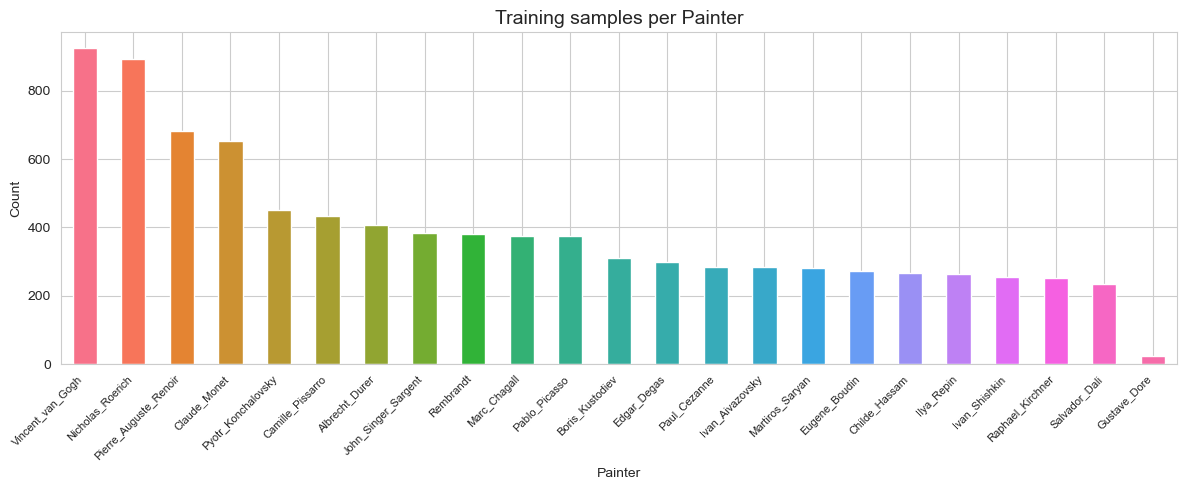

Min: 25 | Max: 925 | Mean: 391.0


In [35]:
# ── Class distribution ────────────────────────────────────────────
train_counts = df_train_final['label'].value_counts()
plt.figure(figsize=(max(12, NUM_CLASSES * 0.5), 5))
train_counts.plot(kind='bar', color=sns.color_palette('husl', NUM_CLASSES))
plt.title('Training samples per Painter', fontsize=14)
plt.xlabel('Painter'); plt.ylabel('Count')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout(); plt.savefig('class_distribution.png', dpi=150); plt.show()
print(f'Min: {train_counts.min()} | Max: {train_counts.max()} | Mean: {train_counts.mean():.1f}')

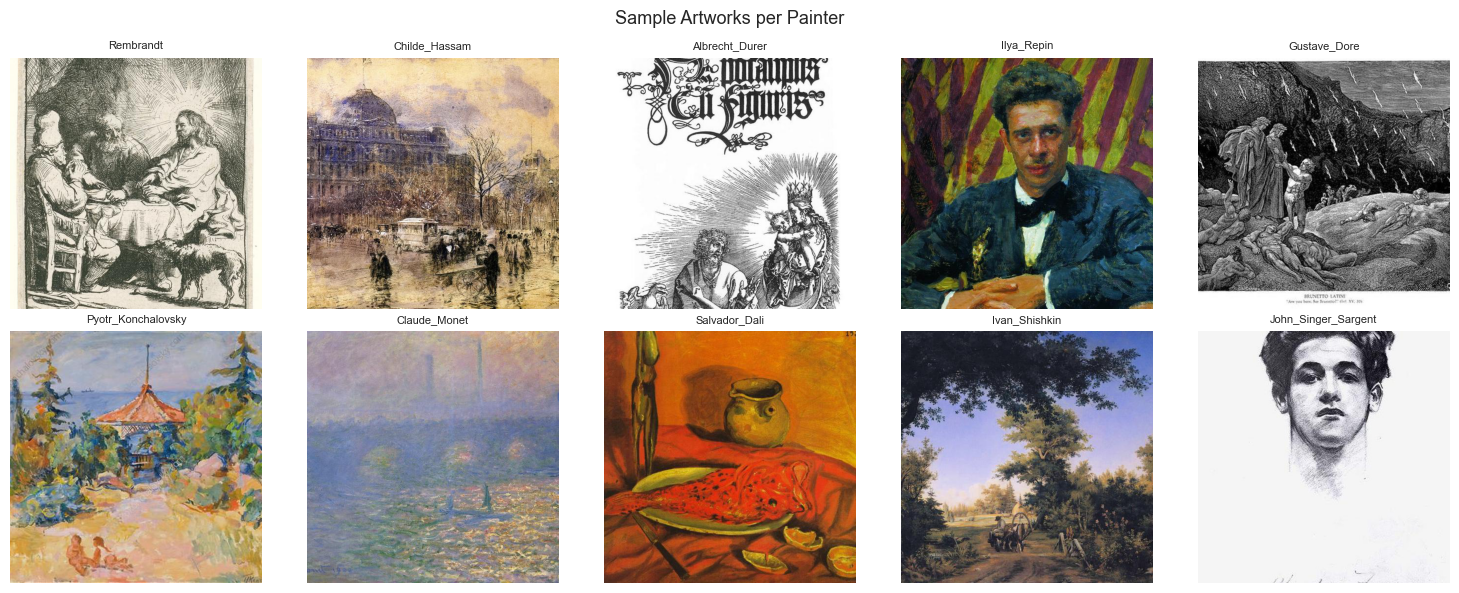

In [36]:
# ── Sample images ─────────────────────────────────────────────────
n_show = min(10, NUM_CLASSES)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, cls in zip(axes.flatten(), random.sample(class_names, n_show)):
    p = df_train_final[df_train_final['label'] == cls]['path'].sample(1).values[0]
    ax.imshow(mpimg.imread(p)); ax.set_title(cls, fontsize=8); ax.axis('off')
plt.suptitle('Sample Artworks per Painter', fontsize=13)
plt.tight_layout(); plt.savefig('sample_images.png', dpi=150); plt.show()

In [37]:
label_counts = df_train_final['label'].value_counts()
total        = len(df_train_final)
idf_weights  = np.log(total / np.array([label_counts.get(c, 1) for c in class_names]))
idf_weights  = idf_weights / idf_weights.sum() * NUM_CLASSES
CLASS_WEIGHTS = dict(enumerate(idf_weights))

print('Top-10 highest weighted painters:')
cw_df = pd.DataFrame({'painter': class_names, 'weight': idf_weights})
print(cw_df.sort_values('weight', ascending=False).head(10).to_string(index=False))

Top-10 highest weighted painters:
         painter   weight
    Gustave_Dore 1.783038
   Salvador_Dali 1.104172
Raphael_Kirchner 1.081812
   Ivan_Shishkin 1.079426
      Ilya_Repin 1.067772
   Childe_Hassam 1.064361
   Eugene_Boudin 1.059873
 Martiros_Saryan 1.048934
 Ivan_Aivazovsky 1.047862
    Paul_Cezanne 1.046793


In [38]:
train_datagen = ImageDataGenerator(
    rescale            = 1.0 / 255,
    rotation_range     = 20,
    width_shift_range  = 0.1,
    height_shift_range = 0.1,
    zoom_range         = 0.15,
    horizontal_flip    = True,
    brightness_range   = [0.8, 1.2],
    fill_mode          = 'reflect'
)
val_datagen = ImageDataGenerator(rescale=1.0 / 255)

def make_generator(datagen, df, shuffle=True):
    return datagen.flow_from_dataframe(
        dataframe   = df,
        x_col       = 'path',
        y_col       = 'label',
        target_size = (IMG_SIZE, IMG_SIZE),
        color_mode  = 'rgb',
        class_mode  = 'categorical',
        batch_size  = BATCH_SIZE,
        shuffle     = shuffle,
        seed        = SEED,
        classes     = class_names
    )

IDF_WEIGHT_ARRAY = np.array([idf_weights[i] for i in range(NUM_CLASSES)], dtype=np.float32)

def mixup_generator(generator, alpha=MIXUP_ALPHA):
    """Applies Mixup and yields (x, y, sample_weights) — no class_weight needed."""
    while True:
        x1, y1 = next(generator)
        x2, y2 = next(generator)
        n       = min(len(x1), len(x2))
        x1, y1, x2, y2 = x1[:n], y1[:n], x2[:n], y2[:n]
        lam     = np.random.beta(alpha, alpha)
        x_mix   = lam * x1 + (1 - lam) * x2
        y_mix   = lam * y1 + (1 - lam) * y2
        # Sample weight = IDF-weighted average of the two mixed classes
        w1      = y1 @ IDF_WEIGHT_ARRAY   # shape (n,)
        w2      = y2 @ IDF_WEIGHT_ARRAY
        w_mix   = lam * w1 + (1 - lam) * w2
        yield x_mix, y_mix, w_mix

def val_generator_wrapped(generator):
    """Val generator yields (x, y, ones) — uniform weights at evaluation."""
    while True:
        x, y = next(generator)
        yield x, y, np.ones(len(x), dtype=np.float32)

def get_generators():
    train_base      = make_generator(train_datagen, df_train_final, shuffle=True)
    train_gen       = mixup_generator(train_base)
    val_base        = make_generator(val_datagen, df_val, shuffle=False)
    val_gen         = val_generator_wrapped(val_base)
    steps_per_epoch = len(df_train_final) // BATCH_SIZE
    val_steps       = len(df_val) // BATCH_SIZE
    return train_gen, val_gen, steps_per_epoch, val_steps

# Quick test
train_gen_base = make_generator(train_datagen, df_train_final, shuffle=True)
print(f'Classes confirmed: {list(train_gen_base.class_indices.keys())[:5]} ...')
print(f'Steps/epoch: {len(df_train_final)//BATCH_SIZE} | Val steps: {len(df_val)//BATCH_SIZE}')

Found 8992 validated image filenames belonging to 23 classes.
Classes confirmed: ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet'] ...
Steps/epoch: 281 | Val steps: 60


Found 100 validated image filenames belonging to 23 classes.


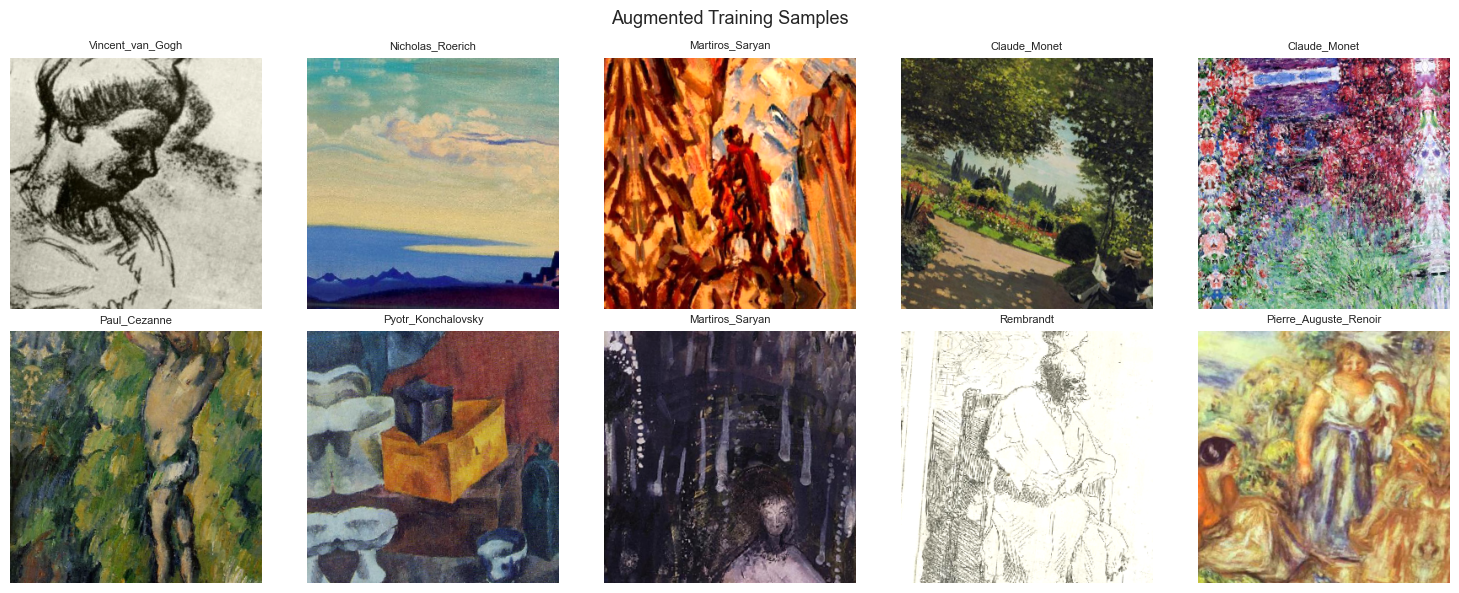

In [39]:
sample_gen = make_generator(train_datagen, df_train_final.head(100), shuffle=True)
sample_imgs, sample_labels = next(sample_gen)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_imgs[i])
    ax.set_title(class_names[sample_labels[i].argmax()], fontsize=8)
    ax.axis('off')
plt.suptitle('Augmented Training Samples', fontsize=13)
plt.tight_layout(); plt.savefig('augmented_samples.png', dpi=150); plt.show()

In [40]:
def cosine_decay_function(epoch, lr):
    if epoch < WARMUP_EPOCHS:
        return float(BASE_LR * (epoch + 1) / WARMUP_EPOCHS)
    progress = (epoch - WARMUP_EPOCHS) / max(MAX_EPOCHS - WARMUP_EPOCHS, 1)
    return float(BASE_LR * 0.5 * (1.0 + np.cos(np.pi * progress)))

def get_callbacks(name, monitor='val_accuracy'):
    return [
        EarlyStopping(monitor=monitor, patience=PATIENCE,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                          patience=3, min_lr=1e-7, verbose=1),
        ModelCheckpoint(f'checkpoints/{name}_best.keras',
                        monitor=monitor, save_best_only=True, verbose=0),
        keras.callbacks.LearningRateScheduler(cosine_decay_function, verbose=0)
    ]

def add_layers(x, num_classes, dropout=0.35):
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(dropout / 2)(x)
    return layers.Dense(num_classes, activation='softmax')(x)

def compile_model(model, lr=BASE_LR):
    model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=lr, weight_decay=WEIGHT_DECAY),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
        metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
    )

print('Callbacks, head builder and compile helper ready.')

Callbacks, head builder and compile helper ready.


In [41]:
# MODEL 1 — DenseNet121
from tensorflow.keras.applications import DenseNet121

inputs_dns = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
base_dns = DenseNet121(
    include_top = False,
    weights = 'imagenet',
    input_tensor = inputs_dns
)
base_dns.trainable = False   # frozen in stage 1

model_dns = Model(inputs_dns, add_layers(base_dns.output, NUM_CLASSES, dropout=0.3),
                  name='DenseNet121')
compile_model(model_dns)
print(f'DenseNet121: {model_dns.count_params()/1e6:.1f}M params')


DenseNet121: 7.3M params


In [42]:
# MODEL 2 — EfficientNetV2S

inputs_env2s = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
base_env2s = EfficientNetV2S(include_top=False, weights='imagenet',
                               input_tensor=inputs_env2s)
base_env2s.trainable = False   # frozen in stage 1

model_env2s = Model(inputs_env2s, add_layers(base_env2s.output, NUM_CLASSES),
                    name='EfficientNetV2S')
compile_model(model_env2s)
print(f'EfficientNetV2S : {model_env2s.count_params()/1e6:.1f}M params')

EfficientNetV2S : 20.7M params


In [43]:
# MODEL 3 — EfficientNetB3

inputs_enb3 = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
base_enb3 = EfficientNetB3(include_top=False, weights='imagenet',
                             input_tensor=inputs_enb3)
base_enb3.trainable = False

model_enb3 = Model(inputs_enb3, add_layers(base_enb3.output, NUM_CLASSES),
                   name='EfficientNetB3')
compile_model(model_enb3)
print(f'EfficientNetB3  : {model_enb3.count_params()/1e6:.1f}M params')

EfficientNetB3  : 11.2M params


In [44]:
# MODEL 4 — ResNet50V2
inputs_rn = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
base_rn = ResNet50V2(include_top=False, weights='imagenet',
                       input_tensor=inputs_rn)
base_rn.trainable = False

model_rn = Model(inputs_rn, add_layers(base_rn.output, NUM_CLASSES),
                 name='ResNet50V2')
compile_model(model_rn)
print(f'ResNet50V2: {model_rn.count_params()/1e6:.1f}M params')

ResNet50V2: 24.1M params


In [45]:
# MODEL 5 — MobileNetV3Large
inputs_mob = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
base_mob = MobileNetV3Large(include_top=False, weights='imagenet',
                              input_tensor=inputs_mob,
                              include_preprocessing=False)
base_mob.trainable = False

model_mob = Model(inputs_mob, add_layers(base_mob.output, NUM_CLASSES, dropout=0.3),
                  name='MobileNetV3Large')
compile_model(model_mob)
print(f'MobileNetV3Large: {model_mob.count_params()/1e6:.1f}M params')

MobileNetV3Large: 3.3M params


In [54]:
# MODEL 6 — Vision Transformer (ViT)
class CLSTokenAndPosEmbed(keras.Layer):
    """Prepends a learnable CLS token and adds positional embeddings."""
    def __init__(self, num_patches, d_model, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.d_model     = d_model
        self.cls_token   = self.add_weight(
            shape=(1, 1, d_model), initializer='zeros',
            trainable=True, name='cls_token'
        )
        self.pos_embed   = self.add_weight(
            shape=(1, num_patches + 1, d_model), initializer='random_normal',
            trainable=True, name='pos_embed'
        )

    def call(self, x):
        batch_size = keras.ops.shape(x)[0]
        cls_tokens = keras.ops.broadcast_to(self.cls_token, (batch_size, 1, self.d_model))
        x          = keras.ops.concatenate([cls_tokens, x], axis=1)
        return x + self.pos_embed


class TransformerBlock(keras.Layer):
    """Single transformer encoder block with pre-LayerNorm."""
    def __init__(self, d_model, num_heads, mlp_dim, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.attn  = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=d_model // num_heads, dropout=dropout
        )
        self.mlp = keras.Sequential([
            layers.Dense(mlp_dim, activation='gelu'),
            layers.Dropout(dropout),
            layers.Dense(d_model),
            layers.Dropout(dropout),
        ])
        self.drop = layers.Dropout(dropout)

    def call(self, x, training=False):
        x_norm   = self.norm1(x)
        attn_out = self.attn(x_norm, x_norm, training=training)
        x        = x + self.drop(attn_out, training=training)
        x        = x + self.mlp(self.norm2(x), training=training)
        return x


def build_vit(
    num_classes,
    img_size   = IMG_SIZE,   # 299
    patch_size = 13,         # 299 / 13 = 23 patches per side → 529 patches total
    d_model    = 256,        # embedding dimension
    num_heads  = 8,
    num_layers = 6,          # transformer depth
    mlp_dim    = 512,
    dropout    = 0.1
):
    num_patches = (img_size // patch_size) ** 2
    inputs      = Input(shape=(img_size, img_size, 3))

    # Normalize to [0,1] then patch-embed via Conv2D
    x = layers.Rescaling(1.0 / 255)(inputs)
    x = layers.Conv2D(
        d_model, kernel_size=patch_size, strides=patch_size, padding='valid'
    )(x)
    x = layers.Reshape((num_patches, d_model))(x)

    # positional embedding
    x = CLSTokenAndPosEmbed(num_patches, d_model)(x)
    x = layers.Dropout(dropout)(x)

    # Transformer encoder blocks
    for i in range(num_layers):
        x = TransformerBlock(d_model, num_heads, mlp_dim, dropout,
                             name=f'transformer_{i}')(x)

    # classification head
    x       = layers.Lambda(lambda t: t[:, 0], name='cls_extract')(x)
    x       = layers.LayerNormalization(epsilon=1e-6)(x)
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs, name='ViT')


model_vit = build_vit(NUM_CLASSES)
compile_model(model_vit, lr=1e-4) 
print(f'ViT : {model_vit.count_params()/1e6:.1f}M params')
print(f'      patches per image: {(IMG_SIZE // 13) ** 2}')


ViT : 3.4M params
      patches per image: 529


In [55]:
# MODEL 7 — VGG16
inputs_vgg = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
base_vgg   = VGG16(
    include_top  = False,
    weights      = 'imagenet',
    input_tensor = inputs_vgg
)
base_vgg.trainable = False   # frozen in stage 1

model_vgg = Model(inputs_vgg, add_layers(base_vgg.output, NUM_CLASSES, dropout=0.4),
                  name='VGG16')
compile_model(model_vgg)
print(f'VGG16 : {model_vgg.count_params()/1e6:.1f}M params')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 17s 0us/step
VGG16 : 14.9M params


In [46]:
# ── Training helper ───────────────────────────────────────────────
histories = {}

def train_model(model, name,
                epochs=MAX_EPOCHS,
                fine_tune_base=None,
                fine_tune_from_layer=-30,
                fine_tune_epochs=FINETUNE_EPOCHS):

    print(f'  Training: {name}')

    train_gen, val_gen, steps, val_steps = get_generators()

    h = model.fit(
        train_gen,
        steps_per_epoch  = steps,
        epochs           = epochs,
        validation_data  = val_gen,
        validation_steps = val_steps,
        callbacks        = get_callbacks(name),
        verbose          = 1
    )
    
    if fine_tune_base is not None:
        print(f'\n--- Fine-tuning top layers of {name} at LR={FINETUNE_LR} ---')
        fine_tune_base.trainable = True
        # Keep lower layers frozen to preserve general features
        for layer in fine_tune_base.layers[:fine_tune_from_layer]:
            layer.trainable = False
        compile_model(model, lr=FINETUNE_LR)

        train_gen2, val_gen2, steps2, val_steps2 = get_generators()
        h_ft = model.fit(
            train_gen2,
            steps_per_epoch  = steps2,
            epochs           = fine_tune_epochs,
            validation_data  = val_gen2,
            validation_steps = val_steps2,
            callbacks        = get_callbacks(f'{name}_ft'),
                verbose          = 1
        )
        # Merging histories
        for k in h.history:
            h.history[k] += h_ft.history.get(k, [])

    histories[name] = h
    print(f'{name} done. Best val acc: {max(h.history["val_accuracy"]):.4f}')
    return h

In [47]:
h1 = train_model(
    model_dns, 'DenseNet121',
    fine_tune_base=base_dns, fine_tune_from_layer=-30
)

  Training: DenseNet121
Found 8992 validated image filenames belonging to 23 classes.
Found 1927 validated image filenames belonging to 23 classes.
Epoch 1/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1387s 5s/step - accuracy: 0.3780 - loss: 2.3774 - top3_acc: 0.5959 - val_accuracy: 0.5708 - val_loss: 1.9227 - val_top3_acc: 0.7901 - learning_rate: 5.0000e-04
Epoch 2/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1348s 5s/step - accuracy: 0.5186 - loss: 2.0442 - top3_acc: 0.7408 - val_accuracy: 0.6526 - val_loss: 1.6761 - val_top3_acc: 0.8510 - learning_rate: 0.0010
Epoch 3/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1359s 5s/step - accuracy: 0.5666 - loss: 1.9500 - top3_acc: 0.7764 - val_accuracy: 0.6675 - val_loss: 1.6207 - val_top3_acc: 0.8565 - learning_rate: 0.0010
Epoch 4/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1347s 5s/step - accuracy: 0.5870 - loss: 1.8797 - top3_acc: 0.7969 - val_accuracy: 0.6966 - val_loss: 1.5411 - val_top3_acc: 0.8749 - learning_rate: 9.6194e-04
Epoch 5/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1342s 5s/step - accu

In [48]:
h2 = train_model(
    model_env2s, 'EfficientNetV2S',
    fine_tune_base=base_env2s, fine_tune_from_layer=-30
)

  Training: EfficientNetV2S
Found 8992 validated image filenames belonging to 23 classes.
Found 1927 validated image filenames belonging to 23 classes.
Epoch 1/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1391s 5s/step - accuracy: 0.0958 - loss: 3.0484 - top3_acc: 0.2504 - val_accuracy: 0.1724 - val_loss: 3.0445 - val_top3_acc: 0.3677 - learning_rate: 5.0000e-04
Epoch 2/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1345s 5s/step - accuracy: 0.1257 - loss: 2.9489 - top3_acc: 0.2931 - val_accuracy: 0.1729 - val_loss: 2.9364 - val_top3_acc: 0.3745 - learning_rate: 0.0010
Epoch 3/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1385s 5s/step - accuracy: 0.1382 - loss: 2.8175 - top3_acc: 0.3231 - val_accuracy: 0.1968 - val_loss: 2.8563 - val_top3_acc: 0.3863 - learning_rate: 0.0010
Epoch 4/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1412s 5s/step - accuracy: 0.1529 - loss: 2.7577 - top3_acc: 0.3484 - val_accuracy: 0.2232 - val_loss: 2.8142 - val_top3_acc: 0.4311 - learning_rate: 9.6194e-04
Epoch 5/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1373s 5s/step - 

In [50]:
h3 = train_model(
    model_enb3, 'EfficientNetB3',
    fine_tune_base=base_enb3, fine_tune_from_layer=-20
)

  Training: EfficientNetB3
Found 8992 validated image filenames belonging to 23 classes.
Found 1927 validated image filenames belonging to 23 classes.
Epoch 1/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1832s 7s/step - accuracy: 0.1167 - loss: 2.8289 - top3_acc: 0.2814 - val_accuracy: 0.1479 - val_loss: 3.0372 - val_top3_acc: 0.3375 - learning_rate: 5.0000e-04
Epoch 2/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1143s 4s/step - accuracy: 0.1189 - loss: 2.8197 - top3_acc: 0.2859 - val_accuracy: 0.1443 - val_loss: 3.0353 - val_top3_acc: 0.3370 - learning_rate: 0.0010
Epoch 3/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 999s 4s/step - accuracy: 0.1212 - loss: 2.8163 - top3_acc: 0.2873 - val_accuracy: 0.1351 - val_loss: 3.0071 - val_top3_acc: 0.3567 - learning_rate: 0.0010
Epoch 4/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 998s 4s/step - accuracy: 0.1203 - loss: 2.8081 - top3_acc: 0.2930 - val_accuracy: 0.1398 - val_loss: 2.9780 - val_top3_acc: 0.3573 - learning_rate: 9.6194e-04
Epoch 5/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 987s 4s/step - accu

In [51]:
h4 = train_model(
    model_rn, 'ResNet50V2',
    fine_tune_base=base_rn, fine_tune_from_layer=-20
)

  Training: ResNet50V2
Found 8992 validated image filenames belonging to 23 classes.
Found 1927 validated image filenames belonging to 23 classes.
Epoch 1/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1202s 4s/step - accuracy: 0.3393 - loss: 2.5732 - top3_acc: 0.5539 - val_accuracy: 0.5542 - val_loss: 1.9402 - val_top3_acc: 0.7620 - learning_rate: 5.0000e-04
Epoch 2/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1882s 7s/step - accuracy: 0.4554 - loss: 2.2087 - top3_acc: 0.6862 - val_accuracy: 0.6068 - val_loss: 1.8250 - val_top3_acc: 0.8135 - learning_rate: 0.0010
Epoch 3/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1473s 5s/step - accuracy: 0.5231 - loss: 2.0533 - top3_acc: 0.7454 - val_accuracy: 0.6185 - val_loss: 1.7894 - val_top3_acc: 0.8121 - learning_rate: 0.0010
Epoch 4/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1310s 5s/step - accuracy: 0.5523 - loss: 1.9718 - top3_acc: 0.7747 - val_accuracy: 0.6475 - val_loss: 1.7245 - val_top3_acc: 0.8385 - learning_rate: 9.6194e-04
Epoch 5/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 1281s 5s/step - accur

In [52]:
h5 = train_model(
    model_mob, 'MobileNetV3Large',
    fine_tune_base=base_mob, fine_tune_from_layer=-15
)

  Training: MobileNetV3Large
Found 8992 validated image filenames belonging to 23 classes.
Found 1927 validated image filenames belonging to 23 classes.
Epoch 1/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 594s 2s/step - accuracy: 0.3384 - loss: 2.5172 - top3_acc: 0.5673 - val_accuracy: 0.5958 - val_loss: 1.8508 - val_top3_acc: 0.7958 - learning_rate: 5.0000e-04
Epoch 2/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 586s 2s/step - accuracy: 0.4740 - loss: 2.1560 - top3_acc: 0.7071 - val_accuracy: 0.6438 - val_loss: 1.7000 - val_top3_acc: 0.8281 - learning_rate: 0.0010
Epoch 3/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 584s 2s/step - accuracy: 0.5275 - loss: 2.0337 - top3_acc: 0.7511 - val_accuracy: 0.6665 - val_loss: 1.6526 - val_top3_acc: 0.8427 - learning_rate: 0.0010
Epoch 4/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 579s 2s/step - accuracy: 0.5656 - loss: 1.9362 - top3_acc: 0.7849 - val_accuracy: 0.6485 - val_loss: 1.6396 - val_top3_acc: 0.8575 - learning_rate: 9.6194e-04
Epoch 5/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 579s 2s/step - accu

In [56]:
h6 = train_model(
    model_vit, 'ViT'
)

  Training: ViT
Found 8992 validated image filenames belonging to 23 classes.
Found 1927 validated image filenames belonging to 23 classes.
Epoch 1/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 2181s 8s/step - accuracy: 0.0704 - loss: 3.1111 - top3_acc: 0.1905 - val_accuracy: 0.1208 - val_loss: 2.9983 - val_top3_acc: 0.3115 - learning_rate: 5.0000e-04
Epoch 2/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 2159s 8s/step - accuracy: 0.0939 - loss: 2.8802 - top3_acc: 0.2391 - val_accuracy: 0.1427 - val_loss: 2.9527 - val_top3_acc: 0.3505 - learning_rate: 0.0010
Epoch 3/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 2155s 8s/step - accuracy: 0.1288 - loss: 2.7460 - top3_acc: 0.3124 - val_accuracy: 0.1509 - val_loss: 2.8826 - val_top3_acc: 0.3810 - learning_rate: 0.0010
Epoch 4/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 2152s 8s/step - accuracy: 0.1544 - loss: 2.6847 - top3_acc: 0.3602 - val_accuracy: 0.2053 - val_loss: 2.7901 - val_top3_acc: 0.4190 - learning_rate: 9.6194e-04
Epoch 5/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 2147s 8s/step - accuracy: 0.

In [58]:
h7 = train_model(
    model_vgg, 'VGG16',
    fine_tune_base=base_vgg, fine_tune_from_layer=-8
)

  Training: VGG16
Found 8992 validated image filenames belonging to 23 classes.
Found 1927 validated image filenames belonging to 23 classes.
Epoch 1/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 3317s 12s/step - accuracy: 0.4511 - loss: 2.1554 - top3_acc: 0.6926 - val_accuracy: 0.5661 - val_loss: 1.8951 - val_top3_acc: 0.7693 - learning_rate: 5.0000e-04
Epoch 2/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 3294s 12s/step - accuracy: 0.4571 - loss: 2.1383 - top3_acc: 0.6983 - val_accuracy: 0.5745 - val_loss: 1.8876 - val_top3_acc: 0.7714 - learning_rate: 0.0010
Epoch 3/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 3274s 12s/step - accuracy: 0.4573 - loss: 2.1416 - top3_acc: 0.7106 - val_accuracy: 0.5641 - val_loss: 1.9106 - val_top3_acc: 0.7710 - learning_rate: 0.0010
Epoch 4/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 3265s 12s/step - accuracy: 0.4720 - loss: 2.1100 - top3_acc: 0.7110 - val_accuracy: 0.5673 - val_loss: 1.8772 - val_top3_acc: 0.7842 - learning_rate: 9.6194e-04
Epoch 5/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 3227s 11s/step - accur

KeyboardInterrupt: 

In [ ]:
# Plot
def plot_history(history, name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'{name}', fontsize=13)
    axes[0].plot(history.history['accuracy'],     label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Val')
    axes[0].set_title('Accuracy'); axes[0].legend()
    axes[1].plot(history.history['loss'],     label='Train')
    axes[1].plot(history.history['val_loss'], label='Val')
    axes[1].set_title('Loss'); axes[1].legend()
    plt.tight_layout()
    plt.savefig(f'history_{name}.png', dpi=150)
    plt.show()

for name, h in histories.items():
    plot_history(h, name)

In [ ]:
# Summary table
models_dict = {
    'DenseNet121'    : model_dns,
    'EfficientNetV2S': model_env2s,
    'EfficientNetB3' : model_enb3,
    'ResNet50V2'     : model_rn,
    'MobileNetV3Large': model_mob
}

_, val_gen_eval, _, _ = get_generators()
results = {}
for name, model in models_dict.items():
    if name not in histories:
        continue
    val_gen_eval = make_generator(val_datagen, df_val, shuffle=False)
    scores = model.evaluate(val_gen_eval, verbose=0)
    results[name] = {
        'Val Loss'    : round(scores[0], 4),
        'Val Accuracy': round(scores[1], 4),
        'Top-3 Acc'   : round(scores[2], 4),
        'Params (M)'  : round(model.count_params() / 1e6, 1)
    }

df_results = pd.DataFrame(results).T.sort_values('Val Accuracy', ascending=False)
print('\n=== Model Comparison ===')
print(df_results.to_string())

In [ ]:
# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_results))
w = 0.35
ax.bar(x - w/2, df_results['Val Accuracy'], w, label='Val Accuracy', color='steelblue')
ax.bar(x + w/2, df_results['Top-3 Acc'],   w, label='Top-3 Accuracy', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(df_results.index, rotation=15, ha='right')
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1)
ax.set_title('Model Comparison — Validation Set')
ax.legend()
for i, (acc, top3) in enumerate(zip(df_results['Val Accuracy'], df_results['Top-3 Acc'])):
    ax.text(i - w/2, acc + 0.01, f'{acc:.3f}', ha='center', fontsize=8)
    ax.text(i + w/2, top3 + 0.01, f'{top3:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

In [ ]:
# Best model 
best_name  = df_results['Val Accuracy'].idxmax()
best_model = models_dict[best_name]
print(f'Best model: {best_name}')

val_gen_final = make_generator(val_datagen, df_val, shuffle=False)
y_pred_proba  = best_model.predict(val_gen_final, verbose=1)
y_pred        = np.argmax(y_pred_proba, axis=1)
y_true        = val_gen_final.classes

print('\n=== Classification Report ===')
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

In [ ]:
best_model.save(f'best_model_{best_name}.keras')
df_results.to_csv('model_comparison_results.csv')

print('\n' + '='*60)
print('  FINAL RESULTS SUMMARY')
print('='*60)
print(df_results.to_string())
print(f'\n Best : {best_name}')
print(f'   Val Accuracy : {df_results.loc[best_name, "Val Accuracy"]:.4f}')
print(f'   Top-3 Acc    : {df_results.loc[best_name, "Top-3 Acc"]:.4f}')
print('='*60)
print('\nTechniques used across all models:')
print('  IDF-style class weights')
print('  Label smoothing (0.1)')
print('  Mixup augmentation (alpha=0.4)')
print('  AdamW + cosine LR + linear warmup')
print('  Two-stage fine-tuning (freeze → unfreeze top layers)')
print('  299px input resolution')